# Currents
13 Mar 2026

copy-paste of Vincent's `post-processing.ipynb`, but modified to be 1-click run and can change between output and archive directories.

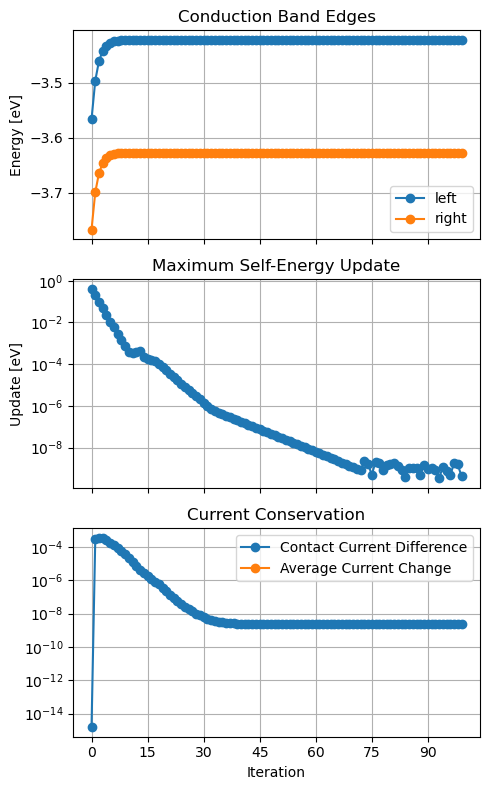

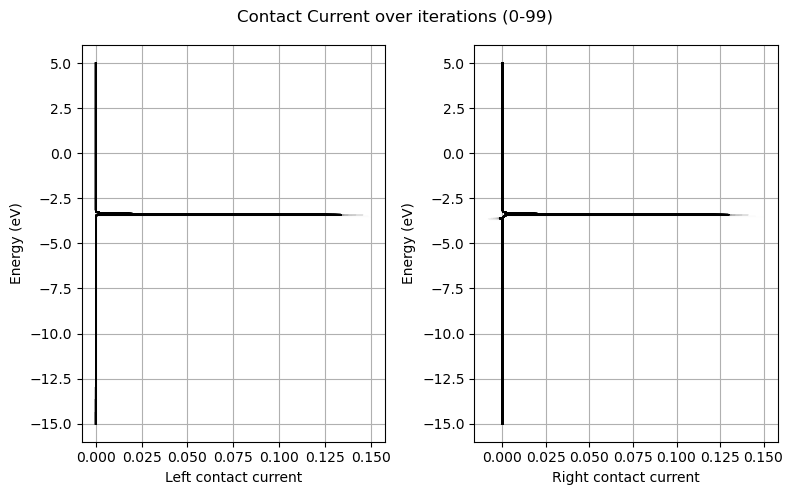

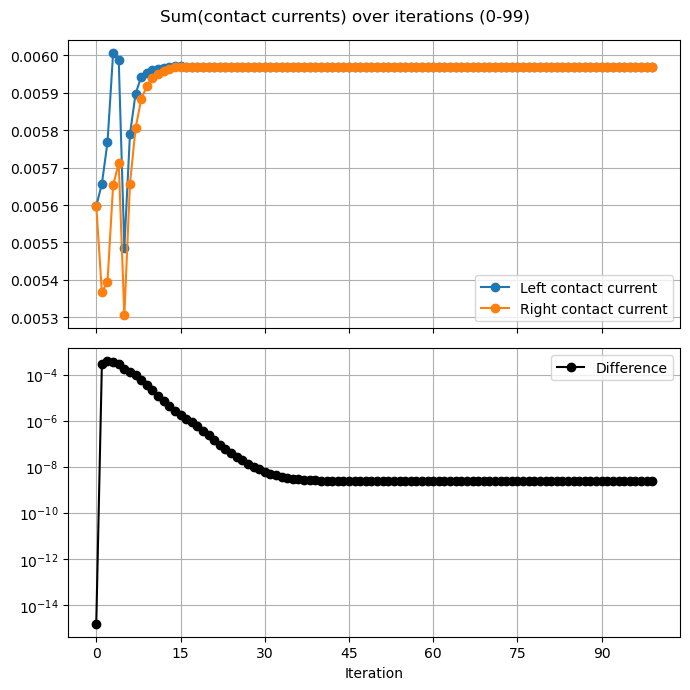

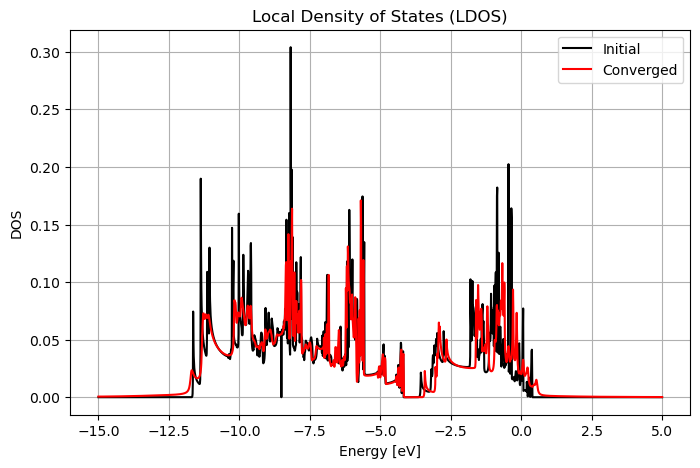

In [35]:
import glob
from pathlib import Path

# data class to hold data across iterations
from scba_container.scba_container import SCBAContainer

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
from scipy.signal import find_peaks

from quatrex.core.config import parse_config

# band-limited study (symmetrization on)
# 20260319_160518_energy201_iter20_reduced
# 20260319_154430_energy2001_iter20_reduced                     # reference, 20 iterations
# 20260319_161440_energy20001_iter5_reduced

# symmetrization off, reference
# 20260410_145015_energy201_iter20_rank125, 201 energies, 125 ranks
# 20260410_145402_energy2001_iter20_rank125, 2001 energies, 125 ranks
# 20260415_141726_energy2001_iter100_rank250, same^, but 100 iterations and 250 ranks
# 20260416_145226_energy2001_iter100_rank250, ^same, but nevp solver is 'full' instead of 'beyn'
# 20260410_151602_energy20001_iter20_rank125, 20001 energies, 125 ranks -- max RAM usage over 512G, ~680G

# sanity check
# 20260326_153844_energy2001_iter20_adaptive_iter1_r1_reduced_sanity_check         # interpolation workflow, but _compute_adaptive_grid returns uniform grid

# adaptive, symmetrization off, varying r
# 20260413_162909_adaptive_energy2001_start1_r1_iter20_rank250
# 20260415_120205_adaptive_energy2001_start1_r1_iter100_rank250         # same as above, but 100 iterations
# 20260416_154143_adaptive_energy2001_start1_r1_iter100_rank250         # ^same, but nevp solver is 'full' instead of 'beyn'
# 20260413_134004_adaptive_energy2001_start1_r5_iter20_rank125
# 20260413_190942_adaptive_energy2001_start1_r5_iter20_rank250      # same as above, but 250 ranks
# 20260413_170105_adaptive_energy2001_start1_r0p5_iter20_rank250

# adaptive, symmetrization off, varying adaptive start iteration
# 20260414_152126_adaptive_energy2001_start2_r1_iter20_rank250
# 20260414_162256_adaptive_energy2001_start5_r1_iter20_rank250


data_files = 'archive'  # 'archive' or 'output'
archive_name = "20260416_145226_energy2001_iter100_rank250"
limit_y_axis = False
limit_x_axis = False

# region: === loading data ===
example_dir = Path("./../../examples/w90/carbon-nanotube/gw")
input_dir = example_dir / "inputs"

archive_dir = example_dir / "archive" / archive_name
output_dir = example_dir / "outputs"


if data_files == 'archive':
    data_dir = archive_dir
    config_dir = archive_dir
elif data_files == 'output':
    config_dir = example_dir 
    data_dir = output_dir

config = parse_config(config_dir / "quatrex_config.toml")

max_idx = 43823  # total nnz entries - 1
data_file_prefix = data_dir / "visualize_scba"
sample_indices = np.load(f"{data_file_prefix}_sample_indices.npy")
num_samples = len(sample_indices)

SCBADataObj = SCBAContainer(
    max_iterations=config.scba.max_iterations,
    energy_window_min=config.electron.energy_window_min,
    energy_window_max=config.electron.energy_window_max,
    energy_window_num=config.electron.energy_window_num,
    num_samples=num_samples,
)

SCBADataObj.load_sample_indices(data_file_prefix)
SCBADataObj.load_adaptive_grids(data_dir)

for i in range(config.scba.max_iterations):
    SCBADataObj.load_g_data(data_file_prefix, iteration=i)
    SCBADataObj.load_p_data(data_file_prefix, iteration=i)
    SCBADataObj.load_w_data(data_file_prefix, iteration=i)
    SCBADataObj.load_sigma_data(data_file_prefix, iteration=i)

with open(config_dir / "out.txt") as f:
    out = f.readlines()

maximum_self_energy_updates = [
    float(line.split()[-1]) for line in out if "Maximum Self-Energy Update" in line
]
average_current_changes = [
    float(line.split()[-1]) for line in out if line.startswith("Average Current Change")
]
relative_average_current_changes = [
    float(line.split()[-1]) for line in out if "Relative Average Current Change" in line
]
current_differences = [
    float(line.split()[-1]) for line in out if "Current Difference" in line
]
relative_current_conservations = [
    float(line.split()[-1]) for line in out if "Relative Current Conservation" in line
]
right_conduction_band_edges = [
    float(line.split()[-1]) for line in out if "Updating conduction band" in line
]
left_conduction_band_edges = [
    float(line.split()[-2].strip(","))
    for line in out
    if "Updating conduction band" in line
]
iterations = [int(line.split()[-1]) for line in out if "Iteration" in line]

# liyongda (01 Apr 2026): convert to numpy arrays for easier indexing
maximum_self_energy_updates = np.array(maximum_self_energy_updates)
average_current_changes = np.array(average_current_changes)
relative_average_current_changes = np.array(relative_average_current_changes)
current_differences = np.array(current_differences)
relative_current_conservations = np.array(relative_current_conservations)
right_conduction_band_edges = np.array(right_conduction_band_edges)
left_conduction_band_edges = np.array(left_conduction_band_edges)
iterations = np.array(iterations)


left_files = glob.glob(str(data_dir / "i_left_*.npy"))
right_files = glob.glob(str(data_dir / "i_right_*.npy"))

# liyongda (16 Apr 2026): sort files so it's not ordered like 0, 10, 11, 12, ... , 1, 20
#   but rather 0, 1, 2, ..., 10, 11, 12, ..., 20
left_files = sorted(left_files, key=lambda x: int(x.split("_")[-1].split(".")[0]))
right_files = sorted(right_files, key=lambda x: int(x.split("_")[-1].split(".")[0]))

# endregion

iterations_to_plot = iterations
# iterations_to_plot = iterations[::5]    # every N
# iterations_to_plot = iterations[25:75]    # a range
# iterations_to_plot = [iterations[22]]     # final iteration, wrap in list for consistent indexing
# iterations_to_plot = iterations[-20:]     # last N iterations

plotCurrents = True
plotFadingAlpha = True
plotSumCurrents = True
plotLdosRightContact = True

# region: === plotting ===
if plotCurrents:
    fig, (ax_band_edges, ax_self_energy, ax_current) = plt.subplots(
        3, 1, figsize=(5, 8), sharex=True, layout="tight"
    )
    ax_band_edges.plot(iterations_to_plot, left_conduction_band_edges[iterations_to_plot], marker="o", label="left")
    ax_band_edges.plot(iterations_to_plot, right_conduction_band_edges[iterations_to_plot], marker="o", label="right")
    ax_band_edges.legend()
    # ax_band_edges.set_yscale("log")
    ax_band_edges.set_ylabel("Energy [eV]")
    ax_band_edges.set_title("Conduction Band Edges")
    ax_band_edges.grid()

    ax_self_energy.plot(iterations_to_plot, maximum_self_energy_updates[iterations_to_plot], marker="o")
    ax_self_energy.set_yscale("log")
    ax_self_energy.set_ylabel("Update [eV]")
    ax_self_energy.set_title("Maximum Self-Energy Update")
    ax_self_energy.grid()

    ax_current.plot(
        iterations_to_plot,
        np.abs(current_differences)[iterations_to_plot], label="Contact Current Difference", marker="o"
    )
    ax_current.plot(average_current_changes, label="Average Current Change", marker="o")
    ax_current.set_yscale("log")
    ax_current.set_title("Current Conservation")
    ax_current.legend()
    ax_current.set_xlabel("Iteration")
    ax_current.grid()
    ax_current.xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.show()

if plotFadingAlpha:
    left_currents = np.array([np.load(f) for f in left_files])
    right_currents = np.array([np.load(f) for f in right_files])

    # convert to numpy arrays for easier indexing
    left_currents = np.array(left_currents)
    right_currents = np.array(right_currents)

    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(8, 5), layout="tight")

    num_iterations = iterations_to_plot[-1]
    color = "black"
    linewidth = 1
    markersize = 1

    # for i, (left_current, right_current) in enumerate(zip(left_currents, right_currents)):
    for i in iterations_to_plot:
        left_current = left_currents[i,:]
        right_current = right_currents[i,:]

        # uniform
        if i < config.scba.adaptive_start_iteration or SCBADataObj.adaptive_electron_energies_for_g_sigma is None:
            energies = np.linspace(
                config.electron.energy_window_min,
                config.electron.energy_window_max,
                config.electron.energy_window_num,
            )
            linestyle = "-"

        # adaptive
        else:
            energies = SCBADataObj.adaptive_electron_energies_for_g_sigma
            linestyle = ".-"
        
        alpha = (i + 0.3) / (num_iterations + 0.3)  # add 0.3 to avoid zero alpha for the first iteration

        ax_left.plot(
            -left_current.real, energies, linestyle, linewidth=linewidth, color=color, markersize=markersize, alpha=alpha
        )
        ax_right.plot(
            right_current.real, energies, linestyle, linewidth=linewidth, color=color, markersize=markersize, alpha=alpha
        )
        
        if limit_y_axis:
            ax_left.set_ylim(-4, -3)
            ax_right.set_ylim(-4, -3)

        if limit_x_axis:
            ax_left.set_xlim(0,0.15)
            ax_right.set_xlim(0,0.15)

    ax_left.set_xlabel("Left contact current")
    ax_right.set_xlabel("Right contact current")
    ax_left.set_ylabel("Energy (eV)")
    ax_right.set_ylabel("Energy (eV)")

    ax_left.grid()
    ax_right.grid()
    # ax_left.set_xscale("log")
    # ax_right.set_xscale("log")

    plt.suptitle(f"Contact Current over iterations ({iterations_to_plot[0]}-{iterations_to_plot[-1]})")
    plt.tight_layout()
    plt.show()

if plotSumCurrents:
    fig, (ax_currents, ax_diff) = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
    dE = energies[1] - energies[0]
    ax_currents.plot(
        iterations_to_plot,
        -left_currents.sum(1).real[iterations_to_plot] * dE,
        label="Left contact current",
        marker="o",
    )
    ax_currents.plot(
        iterations_to_plot,
        right_currents.sum(1).real[iterations_to_plot] * dE,
        label="Right contact current",
        marker="o",
    )
    diff = left_currents.sum(1).real * dE + right_currents.sum(1).real * dE
    ax_diff.plot(iterations_to_plot, np.abs(diff[iterations_to_plot]), label="Difference", color="k", marker="o")

    ax_currents.legend()
    ax_currents.grid()
    # ax_currents.set_ylim(0, 1)

    ax_diff.set_xlabel("Iteration")
    ax_diff.set_yscale("log")
    ax_diff.legend()
    ax_diff.grid()
    ax_diff.xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.suptitle(f"Sum(contact currents) over iterations ({iterations_to_plot[0]}-{iterations_to_plot[-1]})")
    plt.tight_layout()

    plt.show()

if plotLdosRightContact:
    files = glob.glob(str(data_dir / "electron_ldos_*.npy"))
    block_size = 32   # liyongda (14 Apr 2026) specified in quatrex_config.toml under device, default is 32

    # DOS of first layer.
    doss = np.array([np.load(f)[:, :block_size].mean(1) for f in files[: iterations[-1]]])
    band_gaps = []

    # uniform
    energies_initial = np.linspace(
        config.electron.energy_window_min,
        config.electron.energy_window_max,
        config.electron.energy_window_num,
    )
    linestyle_initial = "-"

    # adaptive
    if SCBADataObj.adaptive_electron_energies_for_g_sigma is not None:
        energies_converged = SCBADataObj.adaptive_electron_energies_for_g_sigma
        linestyle_converged = ".-"
    else:
        energies_converged = energies_initial
        linestyle_converged = linestyle_initial

    # Find peaks to determine band gaps.
    for i in range(doss.shape[0]):
        peaks = find_peaks(doss[i], height=0.001)[0]
        peak_energies = energies[peaks]
        mask = (peak_energies - config.electron.left_fermi_level) < 0
        band_gaps.append(np.abs(peak_energies[mask].max() - peak_energies[~mask].min()))


    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    ax.plot(
        energies_initial,
        doss[0],
        linestyle_initial,
        color="k",
        label="Initial",
    )
    ax.plot(
        energies_converged,
        doss[-1],
        linestyle_converged,
        color="r",
        label="Converged",
    )
    # ax.set_xlim(-5.5, -2.5)
    # ax.set_ylim(-0.01, 0.1)
    ax.set_xlabel("Energy [eV]")
    ax.set_ylabel("DOS")
    ax.legend()
    ax.grid()

    # add a title
    ax.set_title("Local Density of States (LDOS)")

    plt.show()

# endregion



In [27]:
threshold = 0.2     # converged currents are about 0.125

check_iterations = range(len(iterations))  # check all iterations

for i in check_iterations:
    max_left_idx = np.argmax(np.abs(left_currents[i,:]))
    max_right_idx = np.argmax(np.abs(right_currents[i,:]))

    max_left = left_currents[i,:][max_left_idx]
    max_right = right_currents[i,:][max_right_idx]

    if np.abs(max_left) > threshold or np.abs(max_right) > threshold:
        print(f"Iteration {iterations[i]}: max left current = {max_left.real:6.3f}, max right current = {max_right.real:6.3f}")

Iteration 1: max left current = -1.714, max right current = -1.172
Iteration 2: max left current = -1.360, max right current = -0.862
Iteration 3: max left current = -1.112, max right current = -0.606
Iteration 4: max left current = -0.827, max right current = -0.405
Iteration 5: max left current = -0.569, max right current = -0.255
Iteration 6: max left current = -0.368, max right current = -0.152
Iteration 7: max left current = -0.229, max right current =  0.113


# LDOS
Sum the orbitals dimension in in `block_size` to get a physical dimension.

block between 0 to 23
Using adaptive energies for plotting.


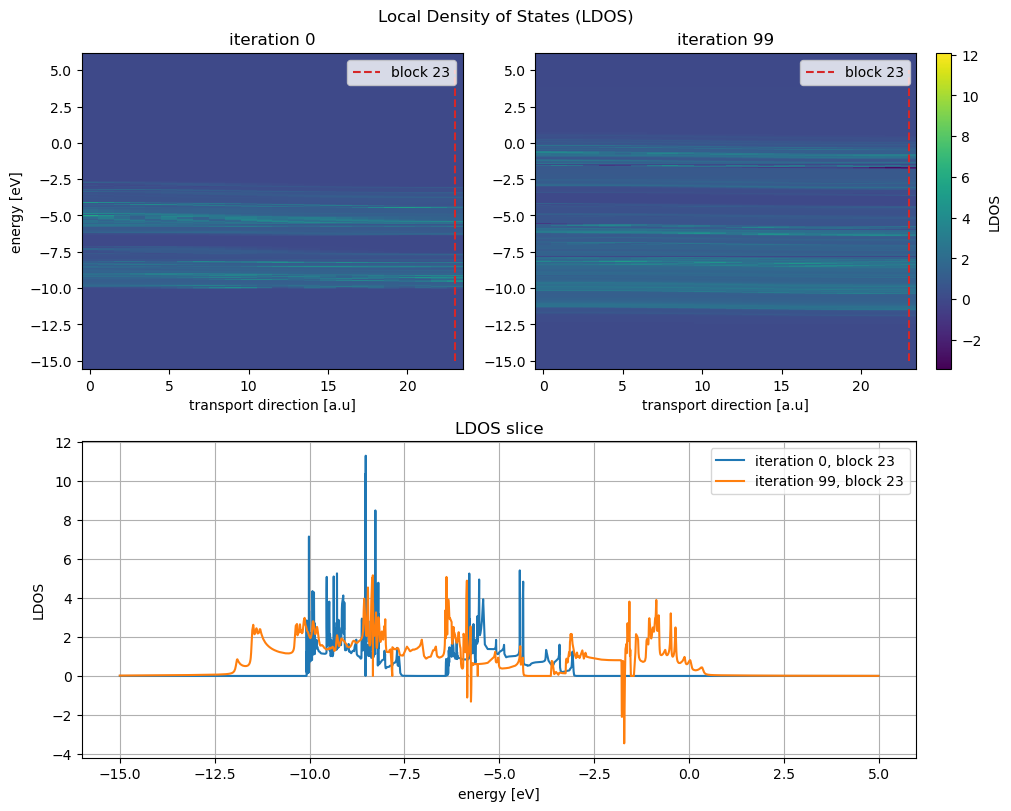

In [28]:
iter_a = 0
iter_b = 99
block_size = 32

block_a = 23
block_b = 23

# region: === load and process data === 
a = np.load(data_dir / f"electron_ldos_{iter_a}.npy")
ldos_a = a.reshape(a.shape[0], -1, block_size).sum(axis=2)

b = np.load(data_dir / f"electron_ldos_{iter_b}.npy")
ldos_b = b.reshape(b.shape[0], -1, block_size).sum(axis=2)

max_block = a.shape[1] // block_size - 1
print(f"block between 0 to {max_block}")
assert(block_a <= max_block), f"block_a should be between 0 and {max_block}"
assert(block_b <= max_block), f"block_b should be between 0 and {max_block}"

use_adaptive = False
if SCBADataObj.adaptive_electron_energies_for_g_sigma is not None:
    energies = SCBADataObj.adaptive_electron_energies_for_g_sigma
    print("Using adaptive energies for plotting.")
    use_adaptive = True
else:
    energies = np.linspace(
        config.electron.energy_window_min,
        config.electron.energy_window_max,
        config.electron.energy_window_num,
    )
    print("Using uniform energies for plotting.")
# endregion

# region: === plotting ===
# use the same color scale for both plots, so set the vmin and vmax to the same value
minmin = min(ldos_a.min(), ldos_b.min())
maxmax = max(ldos_a.max(), ldos_b.max())

fig, axs = plt.subplot_mosaic(
    [
        ["left", "right"],
        ["bottom",   "bottom"]
    ],
    constrained_layout=True,
    figsize=(10, 8),
    sharey=False
)

# explicitly share y-axis between left and right, but not with bottom
axs["left"].sharey(axs["right"])

# need to use pcolormesh instead of imshow to plot non-uniform grids
# im0 = axs['left'].imshow(ldos_a, aspect="auto", origin="lower", vmin=minmin, vmax=maxmax, extent=[0, ldos_a.shape[1], energies[0], energies[-1]])
im0 = axs['left'].pcolormesh(np.arange(ldos_a.shape[1]), energies, ldos_a, shading='auto', vmin=minmin, vmax=maxmax)
axs['left'].set_xlabel("transport direction [a.u]")
axs['left'].set_ylabel("energy [eV]")
axs['left'].vlines(block_a, energies[0], energies[-1], colors='tab:red', linestyles='dashed', label=f'block {block_a}')
axs['left'].set_title(f"iteration {iter_a}")
axs['left'].legend()

# im1 = axs['right'].imshow(ldos_b, aspect="auto", origin="lower", vmin=minmin, vmax=maxmax, extent=[0, ldos_b.shape[1], energies[0], energies[-1]])
im1 = axs['right'].pcolormesh(np.arange(ldos_b.shape[1]), energies, ldos_b, shading='auto', vmin=minmin, vmax=maxmax)
axs['right'].set_xlabel("transport direction [a.u]")
axs['right'].vlines(block_b, energies[0], energies[-1], colors='tab:red', linestyles='dashed', label=f'block {block_b}')
axs['right'].set_title(f"iteration {iter_b}")
axs['right'].legend()

# slice of the LDOS for block_a and block_b
axs['bottom'].plot(energies, ldos_a[:, block_a], label=f"iteration {iter_a}, block {block_a}")
axs['bottom'].plot(energies, ldos_b[:, block_b], label=f"iteration {iter_b}, block {block_b}")
axs['bottom'].set_title(f"LDOS slice")
axs['bottom'].set_xlabel("energy [eV]")
axs['bottom'].set_ylabel("LDOS")
axs['bottom'].grid()
axs['bottom'].legend()

# add space for colorbar
fig.colorbar(im1, label="LDOS")
plt.suptitle(f"Local Density of States (LDOS)")
plt.show()

# endregion



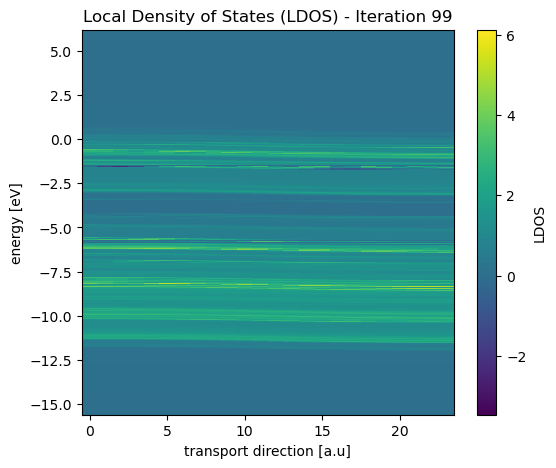

In [5]:
# just plot last iteration separately
plt.figure(figsize=(6, 5))
plt.pcolormesh(np.arange(ldos_b.shape[1]), energies, ldos_b, shading='auto')
plt.xlabel("transport direction [a.u]")
plt.ylabel("energy [eV]")
plt.title(f"Local Density of States (LDOS) - Iteration {iter_b}")
plt.colorbar(label="LDOS")
plt.show()